In [ ]:
"""
Модель Hovorka.

"""

import numpy as np
from scipy.integrate import odeint
from scipy.integrate import ode
from scipy.optimize import fsolve
import pandas as pd


def hovorka_parameters(BW):
    """Функция, возвращающая параметры модели Ховорки для заданного веса тела"""
    V_I = 0.12*BW              # Объем распределения инсулина [L]
    V_G = 0.16*BW              # Объем распределения глюкозы [L]
    F_01 = 0.0097*BW           # Неконтролируемый поток глюкозы [mmol/min]
    EGP_0 = 0.0161*BW          # Производство глюкозы печенью при нулевой концентрации инсулина [mmol/min]

    # Независимые от пациента параметры
    S_IT = 51.2e-4             # Чувствительность инсулина при транспортировке [L/min*mU]
    S_ID = 8.2e-4              # Чувствительность инсулина при утилизации [L/min*mU]
    S_IE = 520e-4              # Чувствительность инсулина при производстве глюкозы [L/mU]

    tau_G = 40                 # Время до максимального поглощения углеводов [мин]
    tau_I = 55                 # Время до максимального поглощения инсулина [мин]

    A_G = 0.8                  # Биодоступность углеводов [1]
    k_12 = 0.066               # Скорость переноса [мин^-1]

    k_a1 = 0.006               # Скорость деактивации инсулина при транспортировке [мин^-1]
    k_b1 = S_IT * k_a1         # Скорость активации инсулина при транспортировке
    k_a2 = 0.06                # Скорость деактивации инсулина при утилизации [мин^-1]
    k_b2 = S_ID * k_a2         # Скорость активации инсулина при утилизации
    k_a3 = 0.03                # Скорость деактивации инсулина при производстве глюкозы [мин^-1]
    k_b3 = S_IE * k_a3         # Скорость активации инсулина при производстве глюкозы

    k_e = 0.138                # Элиминация инсулина из плазмы [мин^-1]

    # Возвращаем все параметры в виде списка
    return [tau_G, tau_I, A_G, k_12, k_a1, k_b1, k_a2, k_b2, k_a3, k_b3, k_e, V_I, V_G, F_01, EGP_0]

def hovorka_model(t, x, u, D, P): #####x t
    """Модель Ховорки для решения ОДУ"""
    #print("Input x:", len(x))  # Отладочный вывод

    D1, D2, S1, S2, Q1, Q2, I, x1, x2, x3, C = x

    tau_G, tau_I, A_G, k_12, k_a1, k_b1, k_a2, k_b2, k_a3, k_b3, k_e, V_I, V_G, F_01, EGP_0 = P

    U_G = D2/tau_G             # Скорость поглощения глюкозы [mmol/min]
    U_I = S2/tau_I             # Скорость поглощения инсулина [mU/min]

    G = Q1/V_G                 # Концентрация глюкозы [mmol/L]

    if G >= 4.5:
        F_01c = F_01           # Потребление глюкозы ЦНС [mmol/min]
    else:
        F_01c = F_01 * G / 4.5

    if G >= 9:
        F_R = 0.003 * (G - 9) * V_G  # Почечная экскреция глюкозы [mmol/min]
    else:
        F_R = 0
        
    # Mass balances/differential equations
    xdot = np.zeros (11);

    xdot[ 0 ] = A_G*D-D1/tau_G                                # dD1
    xdot[ 1 ] = D1/tau_G-U_G                                  # dD2
   
    xdot[ 2 ] = u-S1/tau_I                                    # dS1
    xdot[ 3 ] = S1/tau_I-U_I                                  # dS2
   
    xdot[ 4 ] = -(F_01c+F_R) - x1*Q1 + k_12*Q2 + U_G + max(EGP_0*(1-x3), 0)   # dQ1
    xdot[ 5 ] = x1*Q1-(k_12+x2)*Q2                            # dQ2

    xdot[ 6 ] = U_I/V_I-k_e*I                                 # dI
    
    xdot[ 7 ] = k_b1*I-k_a1*x1                                # dx1
    xdot[ 8 ] = k_b2*I-k_a2*x2                                # dx2
    xdot[ 9 ] = k_b3*I-k_a3*x3                                # dx3

    # ===============
    # CGM delay
    # ===============
    ka_int = 0.073

    xdot[10] = ka_int*(G - C)


    return xdot

def hovorka_model_tuple(x, *pars):
    """HOVORKA DIFFERENTIAL EQUATIONS without time variable
    # t:    Time window for the simulation. Format: [t0 t1], or [t1 t2 t3 ... tn]. [min]
    # x:    Initial conditions
    # u:    Amount of insulin insulin injected [mU/min]
    # D:    CHO eating rate [mmol/min]
    # P:    Model fixed parameters
    #
    """
    u, D, P = pars
    t = 0
    xdot = hovorka_model(t, x, u, D, P)
    return xdot

def simulate_glucose_concentrationHOV(total_time, BW, meals: list, meal_indicator: list, basal): #Я не знаю BW
    """Симуляция концентрации глюкозы через заданное время."""
    # Получаем параметры модели для заданного веса тела
    P = hovorka_parameters(BW)  
    initial_pars = (basal, 0, P)
    x0 = fsolve(hovorka_model_tuple, np.zeros(11), args=initial_pars) ##Определение начального состояния
    print("init bg ", x0[4]/P[12] * 18)
    
    timeline = np.arange(0, total_time, 1)

    BG = []
    BG.append(x0[4]/P[12] * 18)
    X = ode(hovorka_model)
    X.set_integrator('dopri5')
    X.set_initial_value(x0, 0).set_f_params(0, 0, P)

    while X.successful() and X.t < total_time-1:  ##-1 т.к посчитали начальное состояние
        insulin_rate =  meal_indicator[int(X.t)] #basal + meal_indicator[int(X.t)]  Так как данные с simgluco идут уже с basal
        X.set_f_params(insulin_rate, meals[int(X.t)], P)
        solver = X.integrate(X.t + 1)
        BG.append(solver[4]/P[12] * 18) #mmol/l ->mg/dl

    return BG

def simulate_glucose_concentrationHOVTEST(total_time, BW, meals: list, meal_indicator: list, initBG): #Я не знаю BW
    """Симуляция концентрации глюкозы через заданное время."""
    # Получаем параметры модели для заданного веса тела
    P = hovorka_parameters(BW)  
    #initial_pars = (basal, 0, P)
    #x0 = fsolve(hovorka_model_tuple, np.zeros(11), args=initial_pars) ##Определение начального состояния
    #print("init bg ", x0[4]/P[12] * 18)
    x0 = np.zeros(11)
    x0[4] = initBG * P[12]/18

    BG = []
    BG.append(x0[4]/P[12] * 18)
    X = ode(hovorka_model)
    X.set_integrator('dopri5')
    X.set_initial_value(x0, 0).set_f_params(0, 0, P)

    while X.successful() and X.t < total_time-1:  ##-1 т.к посчитали начальное состояние
        insulin_rate =  meal_indicator[int(X.t)] #basal + meal_indicator[int(X.t)]  Так как данные с simgluco идут уже с basal
        X.set_f_params(insulin_rate, meals[int(X.t)], P)
        solver = X.integrate(X.t + 1)
        BG.append(solver[4]/P[12] * 18) #mmol/l ->mg/dl

    return BG

def simulate_glucose_concentrationHOVITER(total_time, BW, meals: list, meal_indicator: list, basal, forecast_steps=10): 
    """Симуляция концентрации глюкозы с прогнозом."""
    P = hovorka_parameters(BW)  
    initial_pars = (basal, 0, P)
    x0 = fsolve(hovorka_model_tuple, np.zeros(11), args=initial_pars)  # Начальное состояние
    print("init bg ", x0[4] / P[12] * 18)

    BG = [x0[4] / P[12] * 18]
    hov_horizon = []
    
    X = ode(hovorka_model)
    X.set_integrator('dopri5')
    X.set_initial_value(x0, 0).set_f_params(0, 0, P)

    while X.successful() and X.t < total_time - 1:  
        insulin_rate = meal_indicator[int(X.t)]
        X.set_f_params(insulin_rate, meals[int(X.t)], P)
        X.set_f_params(insulin_rate, meals[int(X.t)], P)
        solver = X.integrate(X.t + 1)
        BG.append(solver[4] / P[12] * 18)

        # Сохраняем текущее состояние
        current_state = X.y.copy()
        current_time = X.t

        #Генерим данные без введения еды_инсулина, из них берем элемент на forecast_steps итерации. Последнее сгенерированное значение пойдет в подсказку Говорки 
        temp_BG = []
        cho = 0
        if int(X.t)==0:
            ins = insulin_rate
        else:
            ins = min(meal_indicator[int(X.t)],  meal_indicator[int(X.t-1)])
        

        add_data = pd.DataFrame({
            'CHO': [cho] * forecast_steps,
            'insulin':[ins] * forecast_steps
        })
        
        for j in range(forecast_steps):
            X.set_f_params(add_data['insulin'].iloc[j], add_data['CHO'].iloc[j], P)  # Нулевые данные
            if not X.successful():
                break
            temp_state = X.integrate(X.t + 1)
            temp_BG.append(temp_state[4] / P[12] * 18)
        
        hov_horizon.append(temp_BG[-1])
        
        
        # Восстанавливаем состояние
        X.set_initial_value(current_state, current_time)
        print(X.successful(), " ", int(X.t))
    return BG, hov_horizon


def distribute_actionHOV(ACT, TIME, total_time):
    meal_timeline = np.zeros(total_time)
    
    # Вставляем значения из ACT в соответствующие моменты времени из списка TIME
    for act, t in zip(ACT, TIME):
        meal_timeline[t] = act
    
    return meal_timeline



In [ ]:
import matplotlib.pyplot as plt

def graph_output(total_time, glucose_levels_hov):
    # Создаем временной массив для оси X (общий для обоих графиков)
    time_points = np.arange(0, total_time)

    # Построение графика
    plt.figure(figsize=(12, 6))
    print("SS", glucose_levels_hov[500])
    # Добавляем линию из первой подпрограммы (HOVORKA)
    plt.plot(time_points, glucose_levels_hov[:len(time_points)], label='Glucose HOVORKA (mg/dL)', color='blue')


    # Оформление графика
    plt.title('Сравнение уровня глюкозы по двум моделям')
    plt.xlabel('Время (минуты)')
    plt.ylabel('Уровень глюкозы (mg/dL)')
    plt.legend()
    plt.grid(True)

    # Показываем график
    plt.show()

0        149.020000
1        149.020000
2        149.020000
3        149.020000
4        149.020000
            ...    
10071     90.335821
10072     90.335821
10073     90.335821
10074     90.335821
10075     90.985859
Name: BG, Length: 10076, dtype: float64
SS 149.03325165022778


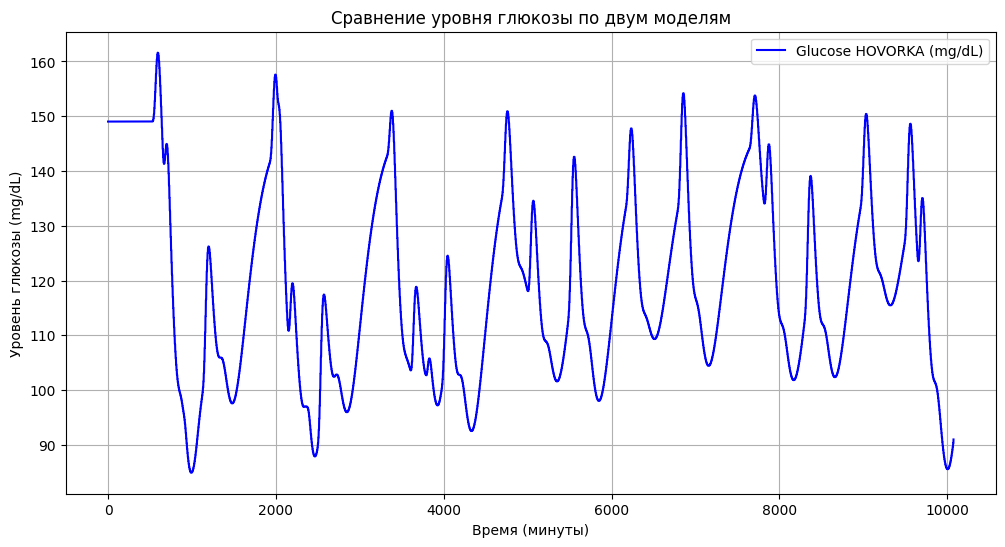

In [3]:
import pandas as pd
#Данные adolescent#001 идут с шагом 5 минут. Для генерации нужен минутный шаг. Заполняю данные с 1 по 4 минуту

# Загрузка данных
data = pd.read_csv("adolescent#001.csv")
data=data.head(2016)
data = data[['Time', 'BG', 'CHO', 'insulin']]

data['Time'] = pd.to_datetime(data['Time'])

# Устанавливаем Time как индекс
data.set_index('Time', inplace=True)

# Создаем новый индекс с шагом в одну минуту
time_index = pd.date_range(start=data.index.min(), end=data.index.max(), freq='min')

# Переиндексация с добавлением минутных шагов
data = data.reindex(time_index).reset_index()
data.rename(columns={'index': 'Time'}, inplace=True)

# Обработка пятиминуток
for i in range(0, len(data), 5):
    if i + 4 < len(data):  # Убедимся, что не выходим за пределы
        # Берем значения BG, CHO и insulin для 0-й и 5-й минут
        bg_value = data.loc[i, 'BG']
        insulin_0 = data.loc[i, 'insulin']
        insulin_5 = data.loc[i + 5, 'insulin'] if i + 5 < len(data) else insulin_0
        insulin_min = min(insulin_0, insulin_5) if not pd.isna(insulin_0) and not pd.isna(insulin_5) else insulin_0
        cho_value = data.loc[i, 'CHO']

        # Обновляем промежуточные минуты
        for j in range(1, 5):
            if i + j < len(data):  # Проверяем, чтобы не выйти за пределы
                data.loc[i + j, 'BG'] = bg_value  # BG фиксирован
                data.loc[i + j, 'CHO'] = 0  # CHO = 0
                data.loc[i + j, 'insulin'] = insulin_min  # insulin — минимум между 0-й и 5-й минутой

# Заполняем пропущенные значения для BG и CHO
data['BG'] = data['BG'].ffill()
data['CHO'] = data['CHO'].fillna(0)
data = data[["BG", "CHO", "insulin"]]
# Сохранение результата
data.to_csv("processed_adolescent.csv", index=False)
print(data['BG'])
graph_output(len(data), data['BG'])


CHO = data['CHO']
INS = data['insulin']
BG = data['BG']


In [14]:
print(len(data))
mmol = 1000/180.16/3 #Перевод в mmol #/3 - из-за структуры Simglucose
CHO_hov = [mmol*i for i in data['CHO']]
const= 1000/3
INS_hov = [const*i for i in data['insulin']]#U/min -> mU/min
BW = 70 #kg  НЕ ЗНАЮ BW С ДАТАСЕТОВ

basal_hov = 5.95 #Используется для определения начального состояние + постоянно вводится дополнительно action

horizon = 60 #min
#glucose_levels_hov = simulate_glucose_concentrationHOVTEST(len(result_data), BW, CHO_hov, INS_hov, 152)
glucose_levels_hov, hov_horizon= simulate_glucose_concentrationHOVITER(len(data), BW, CHO_hov, INS_hov, basal_hov, horizon)


10076
init bg  150.15413627671072
True   1
True   2
True   3
True   4
True   5
True   6
True   7
True   8
True   9
True   10
True   11
True   12
True   13
True   14
True   15
True   16
True   17
True   18
True   19
True   20
True   21
True   22
True   23
True   24
True   25
True   26
True   27
True   28
True   29
True   30
True   31
True   32
True   33
True   34
True   35
True   36
True   37
True   38
True   39
True   40
True   41
True   42
True   43
True   44
True   45
True   46
True   47
True   48
True   49
True   50
True   51
True   52
True   53
True   54
True   55
True   56
True   57
True   58
True   59
True   60
True   61
True   62
True   63
True   64
True   65
True   66
True   67
True   68
True   69
True   70
True   71
True   72
True   73
True   74
True   75
True   76
True   77
True   78
True   79
True   80
True   81
True   82
True   83
True   84
True   85
True   86
True   87
True   88
True   89
True   90
True   91
True   92
True   93
True   94
True   95
True   96
True   97
True 

SS 189.9914972788711


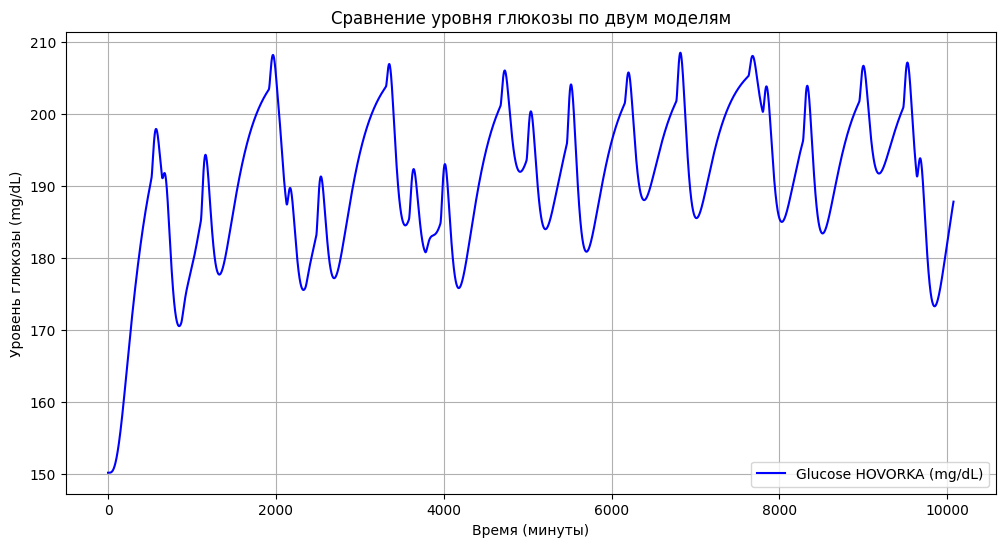

In [15]:
graph_output(len(glucose_levels_hov), glucose_levels_hov)
df_hov_horizon = pd.DataFrame({
    'BG_hov': hov_horizon
})

df_hov_horizon.to_csv('hov_horizon60_adolescent#001.csv', index=False)